# MitoCheck - data exploration 

In [1]:
import sys
import pathlib
import polars as pl

import matplotlib.pyplot as plt

sys.path.append("../../")
from utils.io_utils import load_profiles, load_configs

In [2]:
# set data path
data_dir = pathlib.Path("../0.download-data/data/sc-profiles/").resolve(strict=True)
mitocheck_data = (data_dir / "mitocheck").resolve(strict=True)

# sertting mitocheck paths
mitocheck_profile_path = (mitocheck_data / "mitocheck_concat_profiles.parquet").resolve(
    strict=True
)

# setting config paths
ensg_genes_config_path = (
    mitocheck_data / "mitocheck_ensg_to_gene_symbol_mapping.json"
).resolve(strict=True)
mitocheck_feature_space_config = (
    mitocheck_data / "mitocheck_feature_space_configs.json"
).resolve(strict=True)

# set results output path
results_dir = pathlib.Path("../1.results/").resolve()
results_dir.mkdir(exist_ok=True)

# set output path to store processed profiles
processed_profiles_path = (results_dir / "processed_profiles.parquet").resolve()

In [3]:
# load in configs
ensg_genes_decoder = load_configs(ensg_genes_config_path)
feature_space_configs = load_configs(mitocheck_feature_space_config)

In [38]:
ensg_genes_decoder

{'ENSG00000149503': 'INCENP',
 'ENSG00000173227': 'SYT12',
 'ENSG00000123416': 'TUBA1B',
 'ENSG00000174442': 'ZWILCH',
 'ENSG00000159763': 'PIP',
 'ENSG00000175216': 'CKAP5',
 'ENSG00000180225': 'ENSG00000180225',
 'ENSG00000179698': 'WDR97',
 'ENSG00000164754': 'RAD21',
 'ENSG00000110675': 'ELMOD1',
 'ENSG00000116641': 'DOCK7',
 'ENSG00000186143': 'PRR30',
 'ENSG00000177426': 'TGIF1',
 'ENSG00000198517': 'MAFK',
 'ENSG00000139974': 'SLC38A6',
 'ENSG00000138180': 'CEP55',
 'ENSG00000165675': 'ENOX2',
 'ENSG00000148826': 'NKX6-2'}

In [42]:
ensg_genes_decoder["ENSG00000123416"]

'TUBA1B'

In [4]:
# load in data
mitocheck_df = load_profiles(mitocheck_profile_path)


# removing failed qc
mitocheck_df = mitocheck_df.filter(pl.col("Metadata_Gene") != "failed QC")


# replace "negative_control" and "positive_control" values in Metadata_Gene with
# "negcon" and "poscon" respectivel
mitocheck_df = mitocheck_df.with_columns(
    pl.col("Metadata_Gene").map_elements(
        lambda x: (
            "negcon"
            if x == "negative control"
            else ("poscon" if x == "positive control" else x)
        ),
        return_dtype=pl.String,
    )
)


print(
    "Negative control profiles shape",
    mitocheck_df.filter(pl.col("Mitocheck_Phenotypic_Class") == "negcon").shape,
)
print(
    "Positive control profiles shape",
    mitocheck_df.filter(pl.col("Mitocheck_Phenotypic_Class") == "poscon").shape,
)
print(
    "Positive control treatments:",
    mitocheck_df.filter(pl.col("Mitocheck_Phenotypic_Class") == "poscon")[
        "Metadata_Gene"
    ]
    .unique()
    .to_list(),
)
print(
    "Training profile shape:",
    mitocheck_df.filter(
        (pl.col("Mitocheck_Phenotypic_Class") != "negcon")
        & (pl.col("Mitocheck_Phenotypic_Class") != "poscon")
    ).shape,
)

Negative control profiles shape (779993, 172)
Positive control profiles shape (612059, 172)
Positive control treatments: ['KIF11', 'ENSG00000149503', 'COPB']
Training profile shape: (2916, 172)


Count how many cells per phenotype

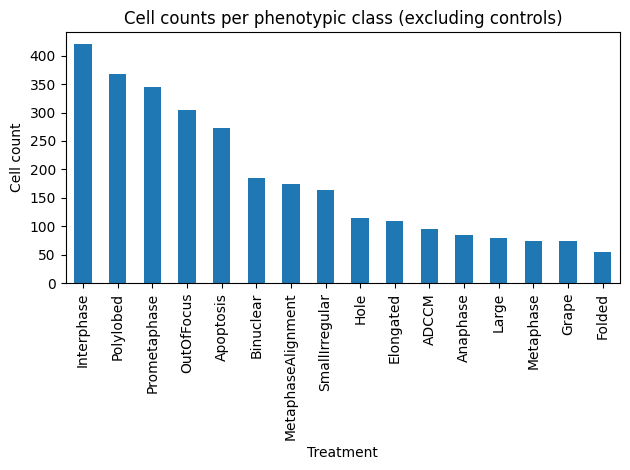

In [ ]:
cell_counts = (
    mitocheck_df.filter(
        (pl.col("Mitocheck_Phenotypic_Class") != "negcon")
        & (pl.col("Mitocheck_Phenotypic_Class") != "poscon")
    )["Mitocheck_Phenotypic_Class"]
    .value_counts()
    .sort("count", descending=True)
)

# plot cell counts per treatments bar plot
cell_counts_df = cell_counts.to_pandas()
cell_counts_df.plot.bar(x="Mitocheck_Phenotypic_Class", y="count", legend=False)

# add title
plt.title("Cell counts per phenotypic class (excluding controls)")
plt.xlabel("Phenotypic classes")
plt.ylabel("Cell count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
# building a dictionary for each gene class with proportion of phenotypes
phenotype_proportions = (
    mitocheck_df.filter(
        (pl.col("Mitocheck_Phenotypic_Class") != "negcon")
        & (pl.col("Mitocheck_Phenotypic_Class") != "poscon")
    )
    .group_by(["Metadata_Gene", "Mitocheck_Phenotypic_Class"])
    .agg(pl.len().alias("count"))
    .with_columns(pl.col("count").sum().over("Metadata_Gene").alias("total_count"))
    .with_columns((pl.col("count") / pl.col("total_count")).alias("proportion"))
    .select(
        [
            "Metadata_Gene",
            "Mitocheck_Phenotypic_Class",
            "count",
            "total_count",
            "proportion",
        ]
    )
)

Metadata_Gene,Mitocheck_Phenotypic_Class,count,total_count,proportion
str,str,u32,u32,f64
"""MYST1""","""Metaphase""",7,57,0.122807
"""MYST1""","""MetaphaseAlignment""",8,57,0.140351
"""PRR30""","""Interphase""",9,24,0.375
"""RAB21""","""Large""",3,24,0.125
"""CEP55""","""Polylobed""",33,39,0.846154
…,…,…,…,…
"""BUB1B""","""Binuclear""",1,41,0.02439
"""POLG""","""Large""",3,30,0.1
"""CDK4""","""Metaphase""",1,55,0.018182


In [49]:
phenotype_proportions.filter(pl.col("Metadata_Gene") == "PAPPA")

Metadata_Gene,Mitocheck_Phenotypic_Class,count,total_count,proportion
str,str,u32,u32,f64
"""PAPPA""","""Apoptosis""",2,34,0.058824
"""PAPPA""","""Prometaphase""",30,34,0.882353
"""PAPPA""","""Metaphase""",2,34,0.058824
